In [25]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Annotated,Literal
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [26]:
load_dotenv()
llm = ChatGroq(model="openai/gpt-oss-120b")

In [27]:
class JokeState(TypedDict):
    topic:str
    joke:str
    explanation:str

In [28]:
def generate_joke(state:JokeState):
    prompt = f'generate a joke on the topic {state["topic"]}.'
    response = llm.invoke(prompt).content
    return {'joke': response}

In [29]:
def generate_explanation(state:JokeState):
    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = llm.invoke(prompt).content
    return {'explanation': response}


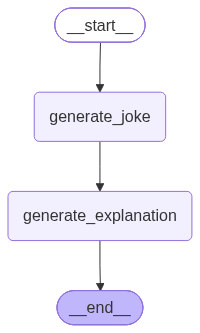

In [30]:
graph = StateGraph(JokeState)
graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()
workflow = graph.compile(checkpointer=checkpointer)
workflow

In [31]:

config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic':'pizza'}, config=config1)

{'topic': 'pizza',
 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to get a *slice* of the action and finally stop feeling so *crust*y! 🍕😄',
 'explanation': '**What makes the joke funny?**  \n\n| Element of the joke | Why it’s funny | How it works as a pun |\n|---------------------|----------------|----------------------|\n| **“Why did the pizza apply for a job?”** | It sets up an absurd mental image: a pizza—a flat, inanimate food—behaving like a person and looking for employment. The surprise of personifying a pizza creates the first chuckle. | The “setup” is a classic “Why did X…?” format that primes the listener for a punch‑line that explains the odd behavior. |\n| **“Because it wanted to get a *slice* of the action…”** | The phrase “a slice of the action” is an idiom meaning “to be part of something exciting or profitable.” Here “slice” is literally what you cut from a pizza, so the word works on two levels at once. | *Slice* → (1) idiomatic “share/portion of the

In [32]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to get a *slice* of the action and finally stop feeling so *crust*y! 🍕😄', 'explanation': '**What makes the joke funny?**  \n\n| Element of the joke | Why it’s funny | How it works as a pun |\n|---------------------|----------------|----------------------|\n| **“Why did the pizza apply for a job?”** | It sets up an absurd mental image: a pizza—a flat, inanimate food—behaving like a person and looking for employment. The surprise of personifying a pizza creates the first chuckle. | The “setup” is a classic “Why did X…?” format that primes the listener for a punch‑line that explains the odd behavior. |\n| **“Because it wanted to get a *slice* of the action…”** | The phrase “a slice of the action” is an idiom meaning “to be part of something exciting or profitable.” Here “slice” is literally what you cut from a pizza, so the word works on two levels at once. | *Slice* → (1) idiomatic “s

In [33]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to get a *slice* of the action and finally stop feeling so *crust*y! 🍕😄', 'explanation': '**What makes the joke funny?**  \n\n| Element of the joke | Why it’s funny | How it works as a pun |\n|---------------------|----------------|----------------------|\n| **“Why did the pizza apply for a job?”** | It sets up an absurd mental image: a pizza—a flat, inanimate food—behaving like a person and looking for employment. The surprise of personifying a pizza creates the first chuckle. | The “setup” is a classic “Why did X…?” format that primes the listener for a punch‑line that explains the odd behavior. |\n| **“Because it wanted to get a *slice* of the action…”** | The phrase “a slice of the action” is an idiom meaning “to be part of something exciting or profitable.” Here “slice” is literally what you cut from a pizza, so the word works on two levels at once. | *Slice* → (1) idiomatic “

In [34]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'pasta'}, config=config2)

{'topic': 'pasta',
 'joke': 'Why did the spaghetti get a promotion?\n\nBecause it knew how to *pasta* the competition and always kept things *al dente*—no one could *ketchup* to its sauce‑y leadership! 🍝😄',
 'explanation': '**Why the joke works**\n\nThe punch‑line is a string of food‑related puns that turn ordinary business‑jargon into a playful, “spaghetti‑themed” compliment. Let’s break it down piece by piece.\n\n| Phrase in the joke | What it sounds like / literal meaning | Why it’s funny |\n|--------------------|----------------------------------------|----------------|\n| **“*pasta* the competition”** | *pasta* → “past” (as in “to get past the competition”) | Swapping the verb “past” for the noodle “pasta” creates a homophonic pun. It also evokes the image of spaghetti literally moving ahead of other dishes. |\n| **“always kept things *al dente*”** | *al dente* is Italian for “to the tooth,” i.e., pasta cooked so it’s firm, not mushy. In a business context “keeping things al dente

In [35]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti get a promotion?\n\nBecause it knew how to *pasta* the competition and always kept things *al dente*—no one could *ketchup* to its sauce‑y leadership! 🍝😄', 'explanation': '**Why the joke works**\n\nThe punch‑line is a string of food‑related puns that turn ordinary business‑jargon into a playful, “spaghetti‑themed” compliment. Let’s break it down piece by piece.\n\n| Phrase in the joke | What it sounds like / literal meaning | Why it’s funny |\n|--------------------|----------------------------------------|----------------|\n| **“*pasta* the competition”** | *pasta* → “past” (as in “to get past the competition”) | Swapping the verb “past” for the noodle “pasta” creates a homophonic pun. It also evokes the image of spaghetti literally moving ahead of other dishes. |\n| **“always kept things *al dente*”** | *al dente* is Italian for “to the tooth,” i.e., pasta cooked so it’s firm, not mushy. In a business context “keep

In [36]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to get a *slice* of the action and finally stop feeling so *crust*y! 🍕😄', 'explanation': '**What makes the joke funny?**  \n\n| Element of the joke | Why it’s funny | How it works as a pun |\n|---------------------|----------------|----------------------|\n| **“Why did the pizza apply for a job?”** | It sets up an absurd mental image: a pizza—a flat, inanimate food—behaving like a person and looking for employment. The surprise of personifying a pizza creates the first chuckle. | The “setup” is a classic “Why did X…?” format that primes the listener for a punch‑line that explains the odd behavior. |\n| **“Because it wanted to get a *slice* of the action…”** | The phrase “a slice of the action” is an idiom meaning “to be part of something exciting or profitable.” Here “slice” is literally what you cut from a pizza, so the word works on two levels at once. | *Slice* → (1) idiomatic “s

In [37]:

list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti get a promotion?\n\nBecause it knew how to *pasta* the competition and always kept things *al dente*—no one could *ketchup* to its sauce‑y leadership! 🍝😄', 'explanation': '**Why the joke works**\n\nThe punch‑line is a string of food‑related puns that turn ordinary business‑jargon into a playful, “spaghetti‑themed” compliment. Let’s break it down piece by piece.\n\n| Phrase in the joke | What it sounds like / literal meaning | Why it’s funny |\n|--------------------|----------------------------------------|----------------|\n| **“*pasta* the competition”** | *pasta* → “past” (as in “to get past the competition”) | Swapping the verb “past” for the noodle “pasta” creates a homophonic pun. It also evokes the image of spaghetti literally moving ahead of other dishes. |\n| **“always kept things *al dente*”** | *al dente* is Italian for “to the tooth,” i.e., pasta cooked so it’s firm, not mushy. In a business context “kee

In [38]:

list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to get a *slice* of the action and finally stop feeling so *crust*y! 🍕😄', 'explanation': '**What makes the joke funny?**  \n\n| Element of the joke | Why it’s funny | How it works as a pun |\n|---------------------|----------------|----------------------|\n| **“Why did the pizza apply for a job?”** | It sets up an absurd mental image: a pizza—a flat, inanimate food—behaving like a person and looking for employment. The surprise of personifying a pizza creates the first chuckle. | The “setup” is a classic “Why did X…?” format that primes the listener for a punch‑line that explains the odd behavior. |\n| **“Because it wanted to get a *slice* of the action…”** | The phrase “a slice of the action” is an idiom meaning “to be part of something exciting or profitable.” Here “slice” is literally what you cut from a pizza, so the word works on two levels at once. | *Slice* → (1) idiomatic “

In [41]:
workflow.get_state({'configurable': {'thread_id': '1','checkpoint_id': '1f197b76-1d61-6714-8000-6004d16d5edd'}})

StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f197b76-1d61-6714-8000-6004d16d5edd'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-08-14T08:08:50.142594+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f197b76-1d5a-61d8-bfff-a8e51e986398'}}, tasks=(PregelTask(id='95d911af-2526-8f6c-7f0a-6834da025427', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to get a *slice* of the action and finally stop feeling so *crust*y! 🍕😄'}),), interrupts=())

In [42]:
workflow.invoke(None,{'configurable': {'thread_id': '1','checkpoint_id': '1f197b76-1d61-6714-8000-6004d16d5edd'}})

{'topic': 'pizza',
 'joke': "Why did the slice of pizza go to therapy?\n\nBecause it couldn't handle the pressure of being *topped* off all the time! 🍕😄",
 'explanation': '**What the joke is doing**\n\nThe humor comes from a *play on words* (a pun) that mixes two different meanings of the same word—*topped*—and then frames the situation as something that would normally require a therapist. Let’s break it down step by step.\n\n| Part of the joke | Literal meaning (pizza world) | Figurative meaning (psychology/ everyday life) |\n|------------------|------------------------------|-----------------------------------------------|\n| “Why did the slice of pizza go to therapy?” | A slice of pizza is a piece of a whole pie. | Therapy is a place people (or, in jokes, objects) go when they feel emotionally overwhelmed or stressed. |\n| “Because it couldn’t handle the pressure of being *topped* off all the time!” | A pizza is *topped* with cheese, sauce, pepperoni, veggies, etc. The slice “receiv

In [43]:

list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': "Why did the slice of pizza go to therapy?\n\nBecause it couldn't handle the pressure of being *topped* off all the time! 🍕😄", 'explanation': '**What the joke is doing**\n\nThe humor comes from a *play on words* (a pun) that mixes two different meanings of the same word—*topped*—and then frames the situation as something that would normally require a therapist. Let’s break it down step by step.\n\n| Part of the joke | Literal meaning (pizza world) | Figurative meaning (psychology/ everyday life) |\n|------------------|------------------------------|-----------------------------------------------|\n| “Why did the slice of pizza go to therapy?” | A slice of pizza is a piece of a whole pie. | Therapy is a place people (or, in jokes, objects) go when they feel emotionally overwhelmed or stressed. |\n| “Because it couldn’t handle the pressure of being *topped* off all the time!” | A pizza is *topped* with cheese, sauce, pepperoni, veggies, et

In [44]:
workflow.update_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f197b76-1d61-6714-8000-6004d16d5edd", "checkpoint_ns": ""}}, {'topic':'samosa'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f197b7e-a63b-6278-8001-663ce84e7fd5'}}

In [45]:

list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f197b7e-a63b-6278-8001-663ce84e7fd5'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-08-14T08:12:39.240767+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f197b76-1d61-6714-8000-6004d16d5edd'}}, tasks=(PregelTask(id='59b02bb3-baf3-2f3d-1d5d-600a01f1e04d', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': "Why did the slice of pizza go to therapy?\n\nBecause it couldn't handle the pressure of being *topped* off all the time! 🍕😄", 'explanation': '**What the joke is doing**\n\nThe humor comes from a *play on words* (a pun) that mixes two different meanings of the same word—*topped*—and then frames the situation as something that wou

In [46]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f197b7e-a63b-6278-8001-663ce84e7fd5"}})

{'topic': 'samosa',
 'joke': 'Why did the samosa go to therapy?\n\nBecause it was tired of being *filled* with everyone’s problems and just wanted to *crisp* up its own life! 😄',
 'explanation': '**What makes the joke funny?**  \n\n| Element of the joke | Why it works (the wordplay or idea behind it) |\n|---------------------|----------------------------------------------|\n| **“Samosa”** | A samosa is a deep‑fried (or baked) triangular pastry that is *filled* with a mixture of spiced potatoes, peas, meat, etc. Because it’s a food that literally holds a filling, it’s a perfect visual metaphor for “holding” something. |\n| **“Went to therapy”** | Therapy is a place where people (or, in jokes, objects) go to sort out emotional baggage, stress, or “problems.” The set‑up creates the expectation that the samosa is a person with feelings, which is already absurd and therefore funny. |\n| **“Tired of being *filled* with everyone’s problems”** | Two meanings of **filled** collide: <br>1. **Lit

In [47]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa', 'joke': 'Why did the samosa go to therapy?\n\nBecause it was tired of being *filled* with everyone’s problems and just wanted to *crisp* up its own life! 😄', 'explanation': '**What makes the joke funny?**  \n\n| Element of the joke | Why it works (the wordplay or idea behind it) |\n|---------------------|----------------------------------------------|\n| **“Samosa”** | A samosa is a deep‑fried (or baked) triangular pastry that is *filled* with a mixture of spiced potatoes, peas, meat, etc. Because it’s a food that literally holds a filling, it’s a perfect visual metaphor for “holding” something. |\n| **“Went to therapy”** | Therapy is a place where people (or, in jokes, objects) go to sort out emotional baggage, stress, or “problems.” The set‑up creates the expectation that the samosa is a person with feelings, which is already absurd and therefore funny. |\n| **“Tired of being *filled* with everyone’s problems”** | Two meanings of **filled** c